# Histograms

In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)
path = homepath + "../meteor/"
sys.path.append(path)
%load_ext autoreload 
%autoreload 2
%matplotlib inline


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from meteor import rsmap
from meteor.utils import cut_resolution

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
from meteor.tv import tv_denoise_difference_map
from meteor.validate import map_negentropy

In [3]:
# from photolyase import *
from compare_conds import get_intersect_and_angle
from photolyase import get_hists, plot_hists, find_wasserstein_dip
from plotting3d import slice_3d, add_fit

from meteorize import *
from photolyase import loading_diffmaps, load_masks,load_mask_config
# from output_eval import panels_3d



In [4]:
folderloc =  homepath+'../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
changing_bit = "6_10ns/10ns"
changing_bit = "2_3ps/3ps"
changing_bit = "7_30ns/30ns"
changing_bit = "3_300ps/300ps"
dataloc_light = folderloc + changing_bit + "_deposit.mtz"
pdbloc_light  = folderloc + changing_bit + '_deposit.pdb'


mask_loc_sphere = homepath+"../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = homepath+"../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
hs_limit = 2.4 
map_sampling = 3




# Data Preparation

## Obtaining F and rho from real data

In [5]:
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

ds_dark = cut_resolution(ds_dark,high_resolution_limit=hs_limit)
ds_light = cut_resolution(ds_light,high_resolution_limit=hs_limit)

ds_light

F       SIGF         IMEAN     SIGIMEAN       KFEXTR  \
H  K L                                                                  
0  0 2         NaN        NaN           NaN          NaN          NaN   
     4         NaN        NaN           NaN          NaN          NaN   
     6  104.692291  28.166756  13096.084961  5096.111328  5241.597656   
     7         NaN        NaN     99.672516   341.696686          NaN   
     8   19.305559   6.283054    474.360016   214.673813   254.361221   
...            ...        ...           ...          ...          ...   
29 5 5         NaN        NaN           NaN          NaN          NaN   
   6 0         NaN        NaN           NaN          NaN          NaN   
     1         NaN        NaN           NaN          NaN          NaN   
     2         NaN        NaN           NaN          NaN          NaN   
     3         NaN        NaN           NaN          NaN          NaN   

        SIGKFEXTR  R-free-flags      F-model  PHIF-model      2FOFCWT  \
H  K L                                                                  
0  0 2        NaN           NaN          NaN         NaN  7156.083984   
     4        NaN            14          NaN         NaN  1888.824463   
     6  23.553352             6  3558.236328         0.0  3249.047852   
     7        NaN           NaN          NaN         NaN          NaN   
     8   90.15493            17   235.932495         0.0    27.087198   
...           ...           ...          ...         ...          ...   
29 5 5        NaN             3          NaN         NaN          NaN   
   6 0        NaN            10          NaN         NaN          NaN   
     1        NaN             8          NaN         NaN          NaN   
     2        NaN            19          NaN         NaN          NaN   
     3        NaN            13          NaN         NaN          NaN   

        PH2FOFCWT  2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H  K L                                                                       
0  0 2        0.0              NaN                NaN         NaN       NaN  
     4        0.0              NaN                NaN         NaN       NaN  
     6        0.0      3249.047852                0.0  582.917175       0.0  
     7        NaN              NaN                NaN         NaN       NaN  
     8        0.0        27.087198                0.0  149.128494     180.0  
...           ...              ...                ...         ...       ...  
29 5 5        NaN              NaN                NaN         NaN       NaN  
   6 0        NaN              NaN                NaN         NaN       NaN  
     1        NaN              NaN                NaN         NaN       NaN  
     2        NaN              NaN                NaN         NaN       NaN  
     3        NaN              NaN                NaN         NaN       NaN  

[56148 rows x 15 columns]

In [6]:
map_dark, map_light = get_scaled_maps(ds_dark, ds_light)



NameError: name 'get_scaled_maps' is not defined

In [ ]:
diffmaps, diffmap_config = loading_diffmaps(
    map_dark=map_dark,
    map_light=map_light,
    changing_bit=changing_bit,
    map_sampling=map_sampling,
)

diffmap_key = "kweighted"
diffmap_key = "tv"
diffmap = diffmaps[diffmap_key]



Reading from photolyase300ps.mtz


In [1]:
kmax = np.max(diffmaps["kweighted"])
kmin= np.min(diffmaps["kweighted"])
tvmax = np.max(diffmaps["tv"])
tvmin = np.min(diffmaps["tv"])
vmin = np.min(diffmaps["vanilla_diffmap"])
vmax = np.max(diffmaps["vanilla_diffmap"])

print(f"vanilla: {vmin:.2f} - {vmax:.2f}")
print(f"kweighted: {kmin:.2f} - {kmax:.2f}")
print(f"tv: {tvmin:.2f} - {tvmax:.2f}")

NameError: name 'np' is not defined

In [47]:
mask_configs = load_mask_config(
        diffmap,
        map_sampling,
        mask_loc_sphere,
        mask_loc_handcraft
)
mask_types = ["ball", "handpicked"]
masks = load_masks(diffmap,map_sampling, mask_configs, mask_types )

extrapolation_factors = np.arange(1,100,2.5)
map_xtrs = make_k_space_xtr(map_dark, diffmap, extrapolation_factors)

Threshold: 0.5


INFO:root:Lowest: 3, Biggest: 4
INFO:root:Intersection: 42.56
INFO:root:Lowest: 9, Biggest: 7
INFO:root:Intersection: 42.14
INFO:root:Lowest: 11, Biggest: 8
INFO:root:Intersection: 41.93
INFO:root:Lowest: 12, Biggest: 8
INFO:root:Intersection: 41.49


Threshold: 0.55


INFO:root:Lowest: 3, Biggest: 4
INFO:root:Intersection: 40.93
INFO:root:Lowest: 10, Biggest: 7
INFO:root:Intersection: 40.62
INFO:root:Lowest: 12, Biggest: 8
INFO:root:Intersection: 40.61
INFO:root:Lowest: 13, Biggest: 8
INFO:root:Intersection: 40.17


Threshold: 0.6000000000000001


...

INFO:root:Lowest: 3, Biggest: 4
INFO:root:Intersection: 37.87
INFO:root:Lowest: 15, Biggest: 8
INFO:root:Intersection: 38.48
INFO:root:Lowest: 16, Biggest: 8
INFO:root:Intersection: 38.19
INFO:root:Lowest: 16, Biggest: 8
INFO:root:Intersection: 38.19


Threshold: 0.8500000000000003


INFO:root:Lowest: 3, Biggest: 4
INFO:root:Intersection: 26.57
INFO:root:Lowest: 22, Biggest: 7
INFO:root:Intersection: 27.33
INFO:root:Lowest: 22, Biggest: 7
INFO:root:Intersection: 27.33
INFO:root:Lowest: 22, Biggest: 7
INFO:root:Intersection: 27.33


Threshold: 0.9000000000000004


INFO:root:Lowest: 3, Biggest: 4
INFO:root:Intersection: 25.24
INFO:root:Lowest: 22, Biggest: 6
INFO:root:Intersection: 26.22
INFO:root:Lowest: 22, Biggest: 7
INFO:root:Intersection: 26.46
INFO:root:Lowest: 22, Biggest: 7
INFO:root:Intersection: 26.46


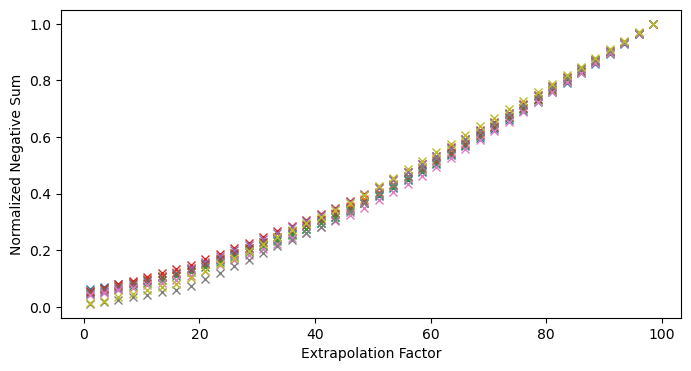

In [48]:
from systematic_plots import plot_one_nse
fig, ax = plt.subplots(1, figsize=(8, 4))
for thresh in np.arange(0.5, 0.95,0.05):
    print(f"Threshold: {thresh}")
    pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold = thresh)

    mask_neg =  neg_blobs>0
    negsum=negsum_meteor(map_xtrs, map_sampling=map_sampling, mask=mask_neg, )
    plot_one_nse( extrapolation_factors, negsum,ax)


INFO:root:Lowest: 3, Biggest: 4
INFO:root:Intersection: 39.17
INFO:root:Lowest: 10, Biggest: 7
INFO:root:Intersection: 39.17
INFO:root:Lowest: 13, Biggest: 8
INFO:root:Intersection: 39.28
INFO:root:Lowest: 15, Biggest: 8
INFO:root:Intersection: 38.71


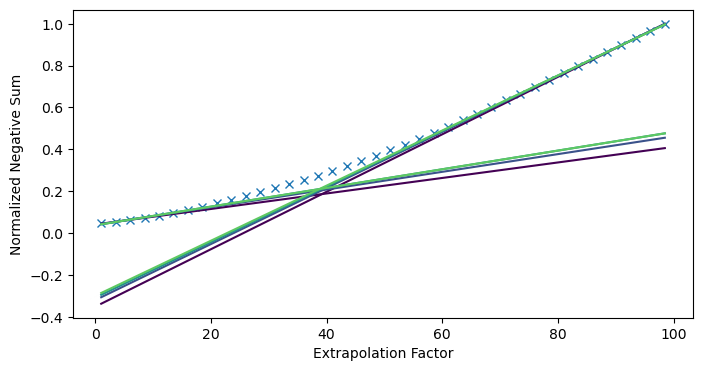

In [49]:
import logging
logging.basicConfig(level=logging.DEBUG)

pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold = 0.6)

mask_neg =  neg_blobs>0
negsum=negsum_meteor(map_xtrs, map_sampling=map_sampling, mask=mask_neg, )
plot_one_nse( extrapolation_factors, negsum)

In [9]:
pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold = 0.4)

mask4 = np.logical_or(pos_blobs>0, neg_blobs>0)

dens_xtrs = [map_xtr.to_3d_numpy_map(map_sampling=map_sampling) for map_xtr in map_xtrs]
rho_dark = map_dark.to_3d_numpy_map(map_sampling=map_sampling)
rmin= np.min(rho_dark)
rmax= np.max(rho_dark)
offset = (rmax-rmin)*0.5
bins = np.linspace(rmin-offset,rmax+offset,50)

0.1 1.8586197103095712
49
49
0.2 2.3913989290495317
49
49
0.30000000000000004 2.5325301204819275
49
49
0.4 1.6367924528301887
49
49
0.5 1.4130434782608696
49
49
0.6000000000000001 1.3962264150943395
49
49


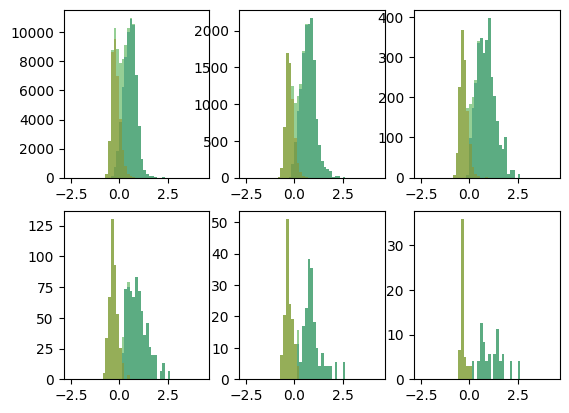

In [10]:
fig, axs = plt.subplots(2,3)
thresholds = np.arange(0.1, 0.7, 0.1)
for ii, thresh in enumerate(thresholds):
    pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold=thresh)
    mask_neg = neg_blobs>0
    mask_pos = pos_blobs>0
    hist_dark_neg, _ = np.histogram(
        rho_dark[mask_neg],
        bins=bins,
    )
    hist_dark_pos, _ = np.histogram(
        rho_dark[mask_pos],
        bins=bins,
    )
    rescale = np.sum(hist_dark_pos)/np.sum(hist_dark_neg)
    print(thresh, rescale)
    hist_dark_inverted = hist_dark_neg*rescale + hist_dark_pos/rescale
    bin_width= np.diff(bins)[0]
    bin_centers = bins[:-1]+bin_width/2
    ax = axs.flat[ii]
    print(len(bin_centers))
    print(len(hist_dark_neg))
    # ax = plt.gca()
    hist_dark_inverted = hist_dark_neg*rescale + hist_dark_pos/rescale
    ax.bar(bin_centers, hist_dark_neg*rescale, alpha=0.5, label="Neg", width=bin_width)
    ax.bar(bin_centers, hist_dark_pos/rescale, alpha=0.5, label="Pos", width=bin_width)
    ax.bar(bin_centers, hist_dark_inverted, alpha=0.5, label="Inv", width=bin_width)
plt.show()

In [22]:
thresh = 0.4
pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold=thresh)
mask_neg = neg_blobs>0
mask_pos = pos_blobs>0
mask_comb = np.logical_or(mask_pos, mask_neg)
from photolyase import get_hists_inverted

dhists, lhists, wdists, bin_centers = get_hists_inverted(dens_xtrs, rho_dark, mask_pos,mask_neg, bins)

# dhists, lhists, wdists, bin_centers = get_hists(dens_xtrs, rho_dark, mask_comb, bins)


Text(0.5, 0.98, 'TV-denoised Difference Map\n')

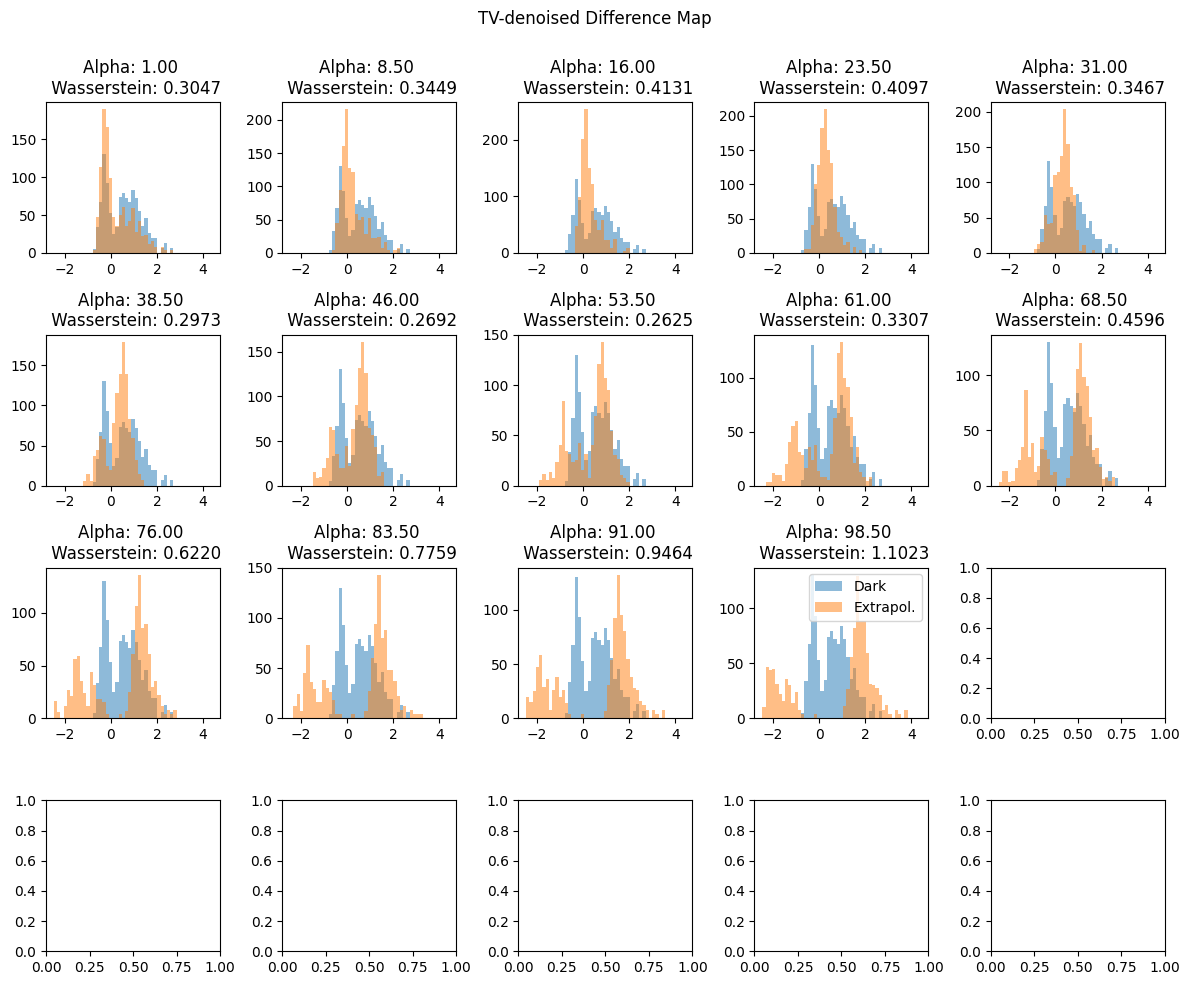

In [23]:

fig,ax1 = plot_hists(dhists[::3], lhists[::3], wdists[::3], bin_centers, extrapolation_factors[::3])
title_str = ""
title_str += diffmap_config[diffmap_key]['title']+'\n'
# title_str += mask_configs[mask_key]['title']
# title_str += f"\nBest histogram match: {xvalue:.0f}"  
fig.suptitle(title_str)


In [ ]:
best_values = {}
fig, ax2 = plt.subplots() 
ln1 = ax2.plot(extrapolation_factors, wdists, label="Histogram Match")
# ax2.plot(extrapolation_factors, cross_correl)    


ax = ax2.twinx()
title_str = ""
title_str += diffmap_config[diffmap_key]['title']+'\n'
title_str += mask_configs[mask_key]['title']
# ax.plot(extrapolation_factors, -neg_sum_real_space, 'x')
ax.plot(extrapolation_factors, -neg_sum_map, 'x',color='orange', label='neg sum')

xvalue = find_wasserstein_dip(extrapolation_factors,wdists)
if xvalue:
    print('hist', xvalue)
    best_values['hist']=(xvalue)
    ax.axvline(xvalue, color="blue", label="best histogram match")
    title_str += f"\nBest histogram match: {xvalue:.0f}"  

if n_largest:
    intersect, angle = get_intersect_and_angle(extrapolation_factors, neg_sum_map, n_largest)
    ax.axvline(intersect, color="red", label="Neg Sum Intersection")
    add_fit(neg_sum_map, extrapolation_factors, n_largest, ax=ax)
    best_values['intersect']=(intersect)
    title_str += f"\n Neg Sum Intersection: {intersect:.2f}"  
lns = [ l for l in ax.lines if l.get_label()[0]!="_"]
lns =  ln1 + lns
labs = [l.get_label() for l in lns ]

ax2.set_ylabel('Wasserstein Distance')
ax2.set_xlabel('Extrapolation Factor')
ax2.set_yscale('log')
ax.set_ylabel(r'$\sum$ Negative Values')
# ax.set_xlim(0,60)    
# ax.set_ylim(0,400)    
ax.legend(lns,labs, loc='lower right')
ax.set_title(title_str)
plt.show()
